# Plotting heatmap of single frame as illustration of monolayer heights

In [1]:
import sys
import json
import imageio
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from cmcrameri import cm
from scipy.ndimage import gaussian_filter
from matplotlib_scalebar.scalebar import ScaleBar


sys.path.append("scripts/utils")
from Microscopes     import Holomonitor, Tomocube
from SegmentedCells  import SegmentedCells
from file_operations import *

data_path = "../../../../hdd_data/silja/Monolayers/"

In [2]:
n0 = Tomocube().n0

dataset = "MDCK_20250904_B1-1"
frame   = 10
measure = "disc"
param   = "h"

In [3]:
config = json.load(open(f"configs/{dataset}.json"))

### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()

h_im, n_im = load_set_of_frames(f"{data_path}height_fields/calibrated/{dataset}", frame, microscope)


In [4]:
if measure == "disc":
    cells = SegmentedCells(f"{data_path}cell_features/raw/{dataset}_cells.p")
    
    A_mean = 1/(cells.density[frame - config["cells"]["fmin"]] / 10**6)
    r_mean = np.sqrt(A_mean / np.pi)
    sigma  = microscope.rblur * r_mean / microscope.pix_to_um
    im_disc = gaussian_filter(h_im, sigma)

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20250904_B1-1_cells.p.


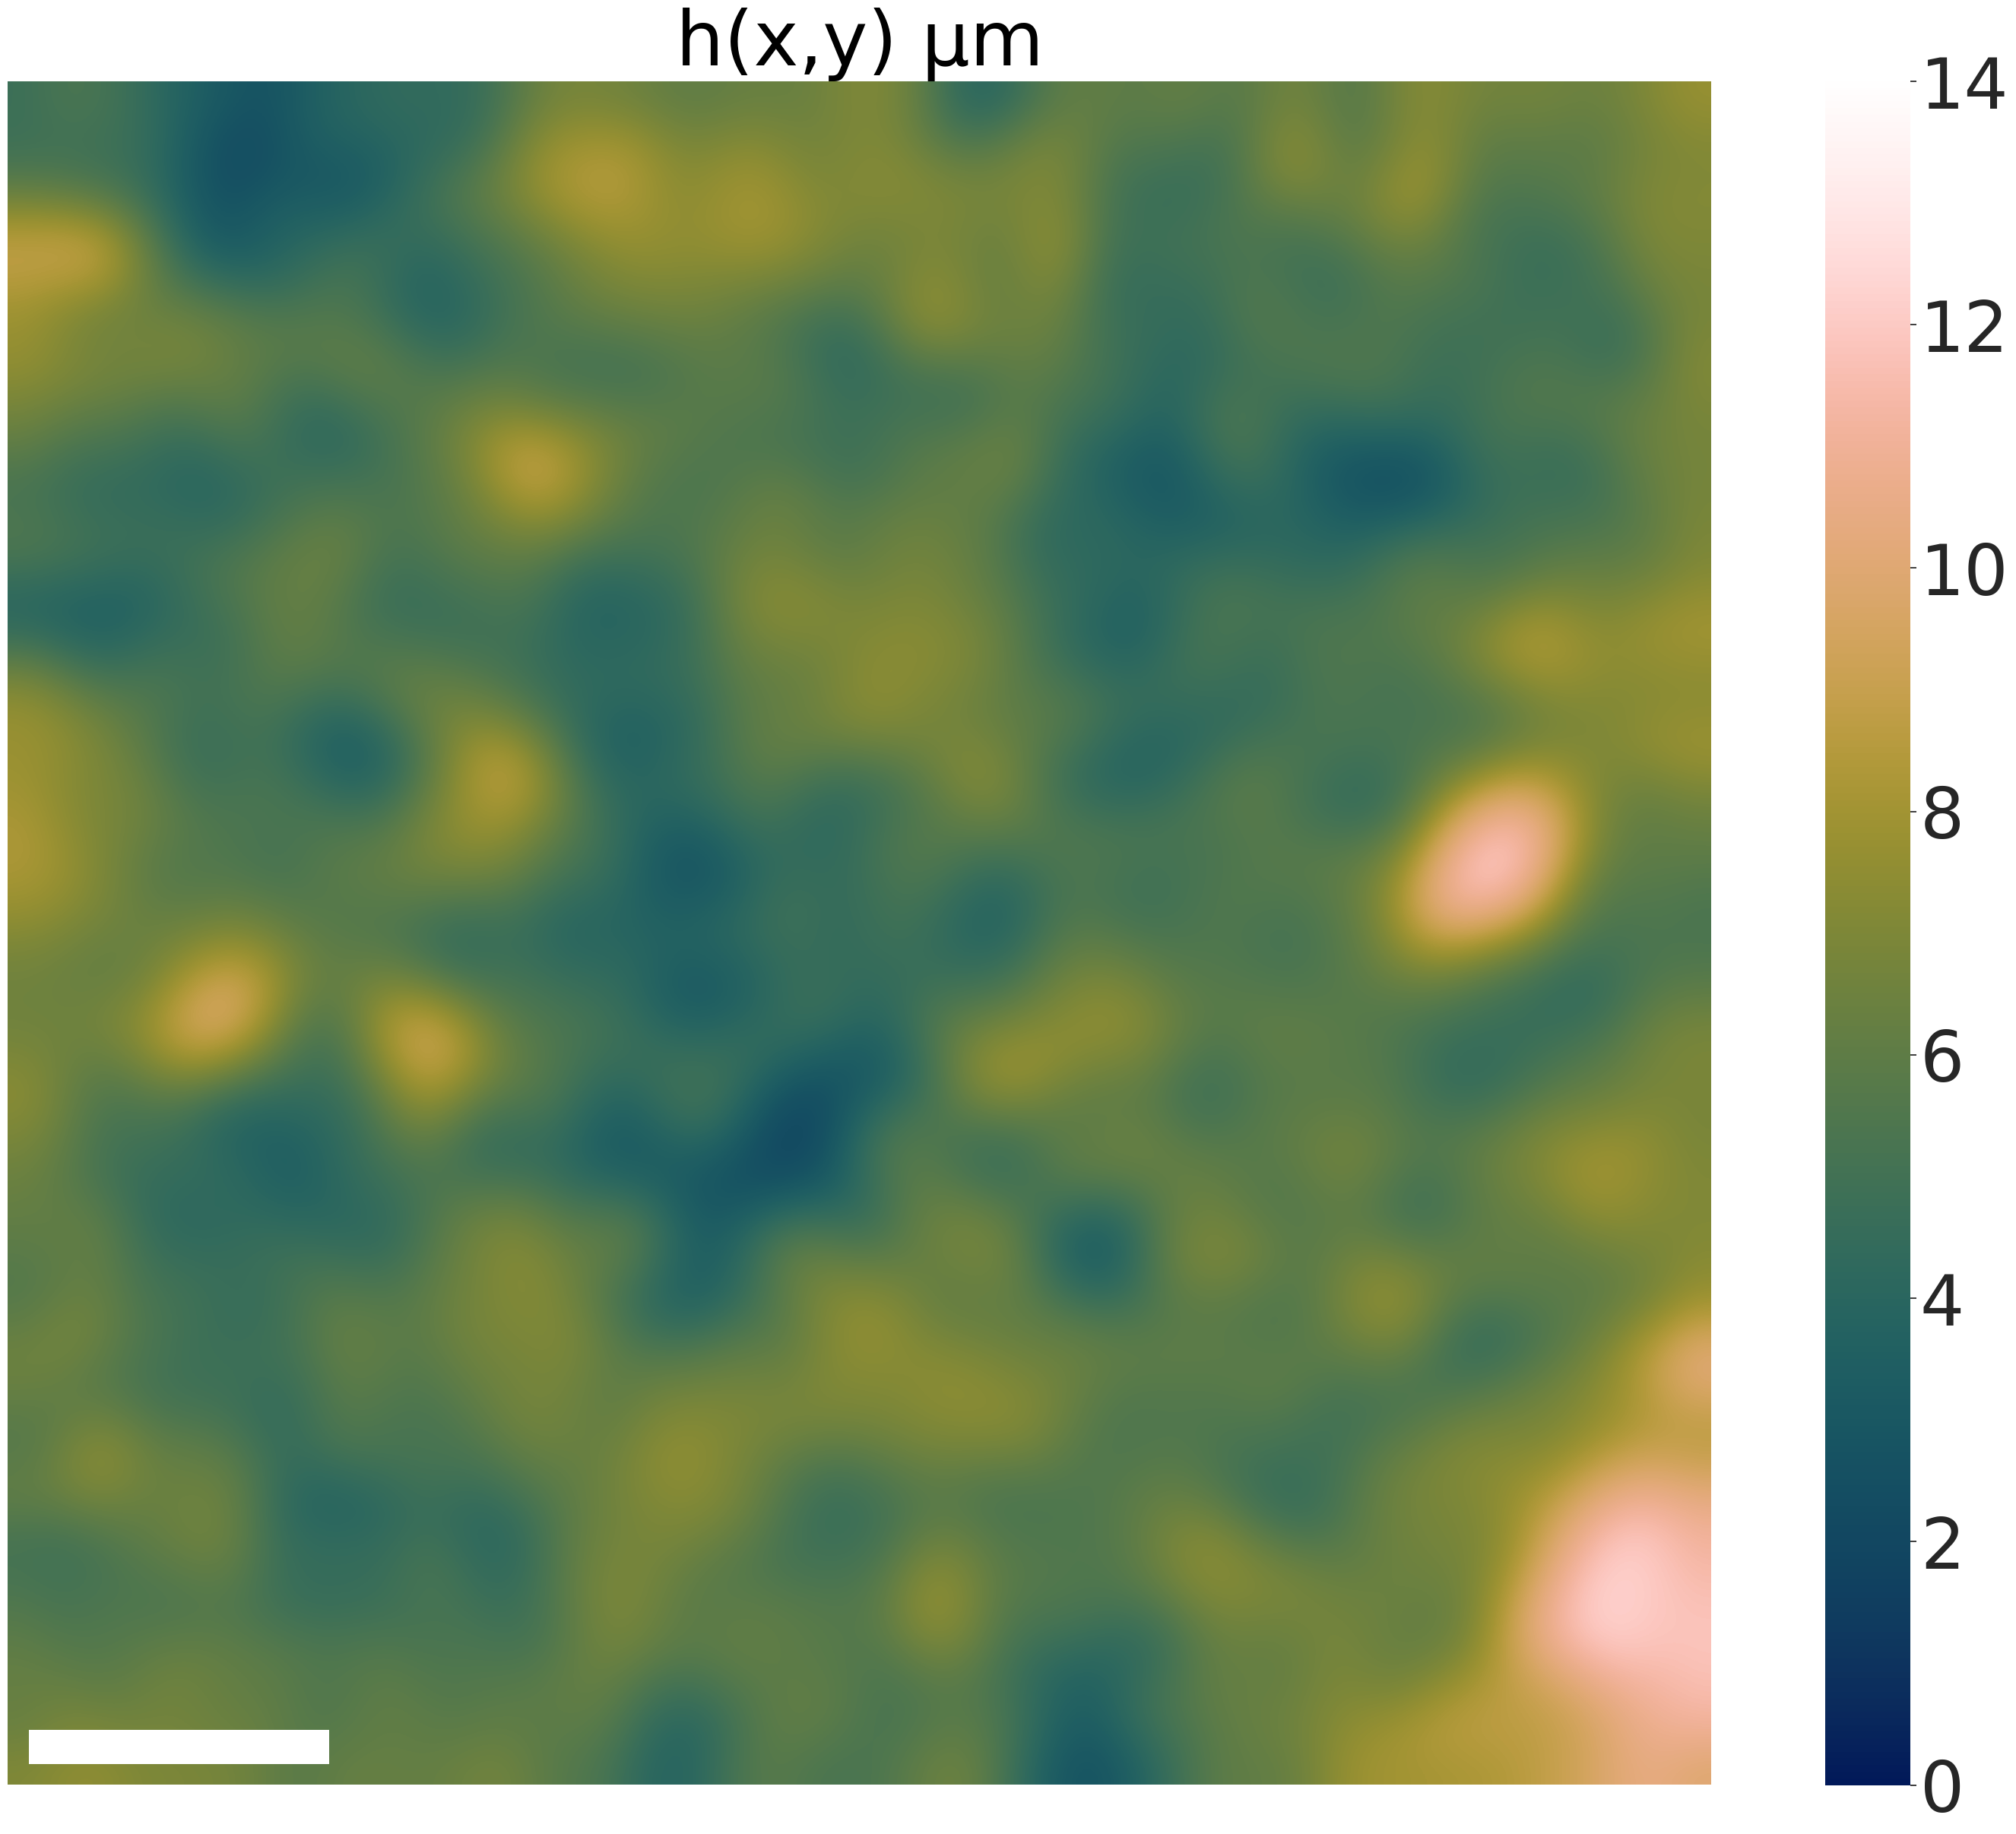

In [5]:
if param == "cd":
    vmin = 0.2
    vmax = -0.2
    cmap = "rocket"

if param == "h":
    vmin = 0
    vmax = 14
    cmap = cm.batlowW

fig, ax = plt.subplots(1,1, figsize=(32,26))
sns.set_theme(style='ticks', palette='bright', font_scale=6)

if measure == "disc":
    #im = (im_disc - n0) / (np.mean(im_disc) - n0) - 1
    im = im_disc
    sns.heatmap(im, square=True, cmap=cmap, xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)
else:
    sns.heatmap(h_im, square=True, cmap=cmap, xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)

sb = ScaleBar(microscope.pix_to_um, 'um', box_alpha=0, color="w", height_fraction=2e-2, scale_loc="none", fixed_value=100)
sb.location = 'lower left'
ax.add_artist(sb)

if param == "cd":
    ax.set(title=r"$c_d(r;x,y)/\bar{c}_d - 1$")
else:
    ax.set(title=rf"{param}(x,y) µm")

fig.tight_layout()

In [6]:
# Save figure
# fig.savefig(f"figs/Elife/subfigures/{param}_{measure}wise_heatmap.png", dpi=100)